# Tuberculosis (TB) Chest X-ray Classification
## Training from Scratch vs Transfer Learning
### Models: Custom CNN · ResNet50 · DenseNet121 · EfficientNet-B0 · **Vision Transformer (ViT-B/16)**

In [1]:
# Install required packages
!pip install -q torch torchvision torchaudio
!pip install -q matplotlib seaborn scikit-learn pillow pandas numpy tqdm
!pip install -q kaggle
print("All packages installed successfully!")


All packages installed successfully!


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms, models
from torchvision.models import (
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)
from tqdm import tqdm
import copy
import time

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cpu


In [3]:
# ============================================================
# ENVIRONMENT DETECTION & DATASET SETUP
# ============================================================

import os, sys
from pathlib import Path

_kaggle_path = Path('/kaggle/input/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database')
_colab_path  = Path('/content/TB_Chest_Radiography_Database')
_local_path  = Path('./TB_Chest_Radiography_Database')

def _in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if _kaggle_path.exists():
    ENV      = 'Kaggle'
    DATA_DIR = _kaggle_path
    print("Environment: Kaggle Notebook  (GPU auto-enabled via Kaggle settings)")

elif _in_colab():
    ENV = 'Colab'
    print("Environment: Google Colab")

    # ── Mount Google Drive (optional – comment out if not using Drive) ──────
    # from google.colab import drive
    # drive.mount('/content/drive')
    # DATA_DIR = Path('/content/drive/MyDrive/TB_Chest_Radiography_Database')

    # ── Download via Kaggle API ──────────────────────────────────────────────
    if not _colab_path.exists():
        print("Dataset not found — downloading from Kaggle...")
        kaggle_json = Path('/root/.kaggle/kaggle.json')
        if not kaggle_json.exists():
            print("Upload your kaggle.json (Kaggle → Settings → API → Create New Token):")
            from google.colab import files
            uploaded = files.upload()              # triggers file-picker dialog
            os.makedirs('/root/.kaggle', exist_ok=True)
            os.replace('/content/kaggle.json', kaggle_json)
            os.chmod(kaggle_json, 0o600)
            print("kaggle.json saved.")

        os.makedirs('/content/kaggle_data', exist_ok=True)
        os.system('kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset '
                  '-p /content/kaggle_data --unzip')
        # Move extracted folder to expected path
        import shutil
        extracted = Path('/content/kaggle_data/TB_Chest_Radiography_Database')
        if extracted.exists():
            shutil.move(str(extracted), str(_colab_path))
        print("Dataset ready.")
    else:
        print("Dataset already present.")

    DATA_DIR = _colab_path

else:
    ENV      = 'Local'
    DATA_DIR = _local_path
    print("Environment: Local")

print(f"DATA_DIR  -> {DATA_DIR}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")

# ============================================================
# CONFIGURATION
# ============================================================

# Hyperparameters
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 7
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 2
NUM_WORKERS   = 2 if ENV != 'Local' else 0   # 0 workers avoids issues on Windows

# Class names
CLASS_NAMES = ['Normal', 'Tuberculosis']

# Train/Val/Test split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print("\nConfiguration:")
print(f"  Image Size:           {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size:           {BATCH_SIZE}")
print(f"  Epochs:               {NUM_EPOCHS}")
print(f"  Learning Rate:        {LEARNING_RATE}")
print(f"  Train/Val/Test Split: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"  Classes:              {CLASS_NAMES}")
print(f"  Num Workers:          {NUM_WORKERS}")


Environment: Local
DATA_DIR  -> TB_Chest_Radiography_Database
DATA_DIR exists: True

Configuration:
  Image Size:           224x224
  Batch Size:           32
  Epochs:               7
  Learning Rate:        0.001
  Train/Val/Test Split: 0.7/0.15/0.15
  Classes:              ['Normal', 'Tuberculosis']
  Num Workers:          0


In [ ]:
# ============================================================
# GPU CHECK  (Colab: Runtime → Change runtime type → GPU → Save)
# ============================================================

import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    mem_free  = (torch.cuda.get_device_properties(0).total_memory
                 - torch.cuda.memory_reserved(0)) / 1e9
    print(f"Total VRAM      : {mem_total:.1f} GB")
    print(f"Free VRAM       : {mem_free:.1f} GB")
else:
    print("\nNo GPU detected.")
    if _in_colab():
        print("To enable GPU in Colab: Runtime → Change runtime type → "
              "Hardware accelerator → GPU (T4 / A100) → Save")
    print("Training will run on CPU — expect slower performance.")


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU name        : Tesla T4
Total VRAM      : 15.6 GB
Free VRAM       : 8.6 GB


In [4]:
# ============================================================
# DATASET EXPLORATION
# ============================================================

# Count images in each class
normal_path = DATA_DIR / 'Normal'
tb_path     = DATA_DIR / 'Tuberculosis'

normal_images = (list(normal_path.glob('*.png')) +
                 list(normal_path.glob('*.jpg')) +
                 list(normal_path.glob('*.jpeg')))
tb_images     = (list(tb_path.glob('*.png')) +
                 list(tb_path.glob('*.jpg')) +
                 list(tb_path.glob('*.jpeg')))

print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)
print(f"Normal images:       {len(normal_images):>5}")
print(f"Tuberculosis images: {len(tb_images):>5}")
print(f"Total images:        {len(normal_images) + len(tb_images):>5}")
print(f"\nClass imbalance ratio: {len(normal_images) / len(tb_images):.1f}:1 (Normal:TB)")

DATASET STATISTICS
Normal images:        3500
Tuberculosis images:   700
Total images:         4200

Class imbalance ratio: 5.0:1 (Normal:TB)


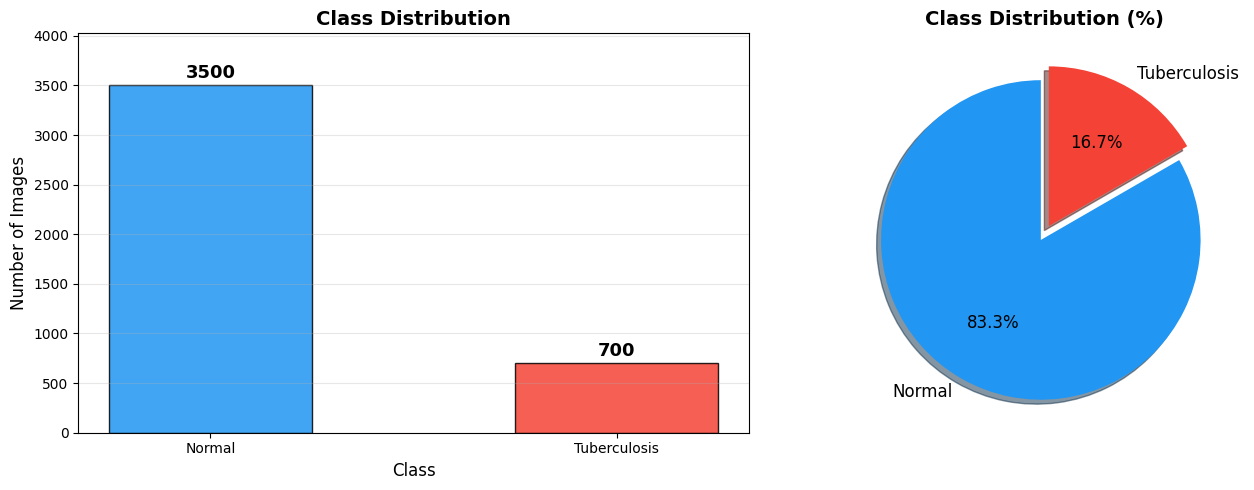

Class distribution plot saved.


In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = [len(normal_images), len(tb_images)]
colors = ['#2196F3', '#F44336']
bars = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'{count}', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
explode = (0.05, 0.05)
axes[1].pie(counts, labels=CLASS_NAMES, autopct='%1.1f%%', colors=colors,
           explode=explode, shadow=True, startangle=90,
           textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution plot saved.")

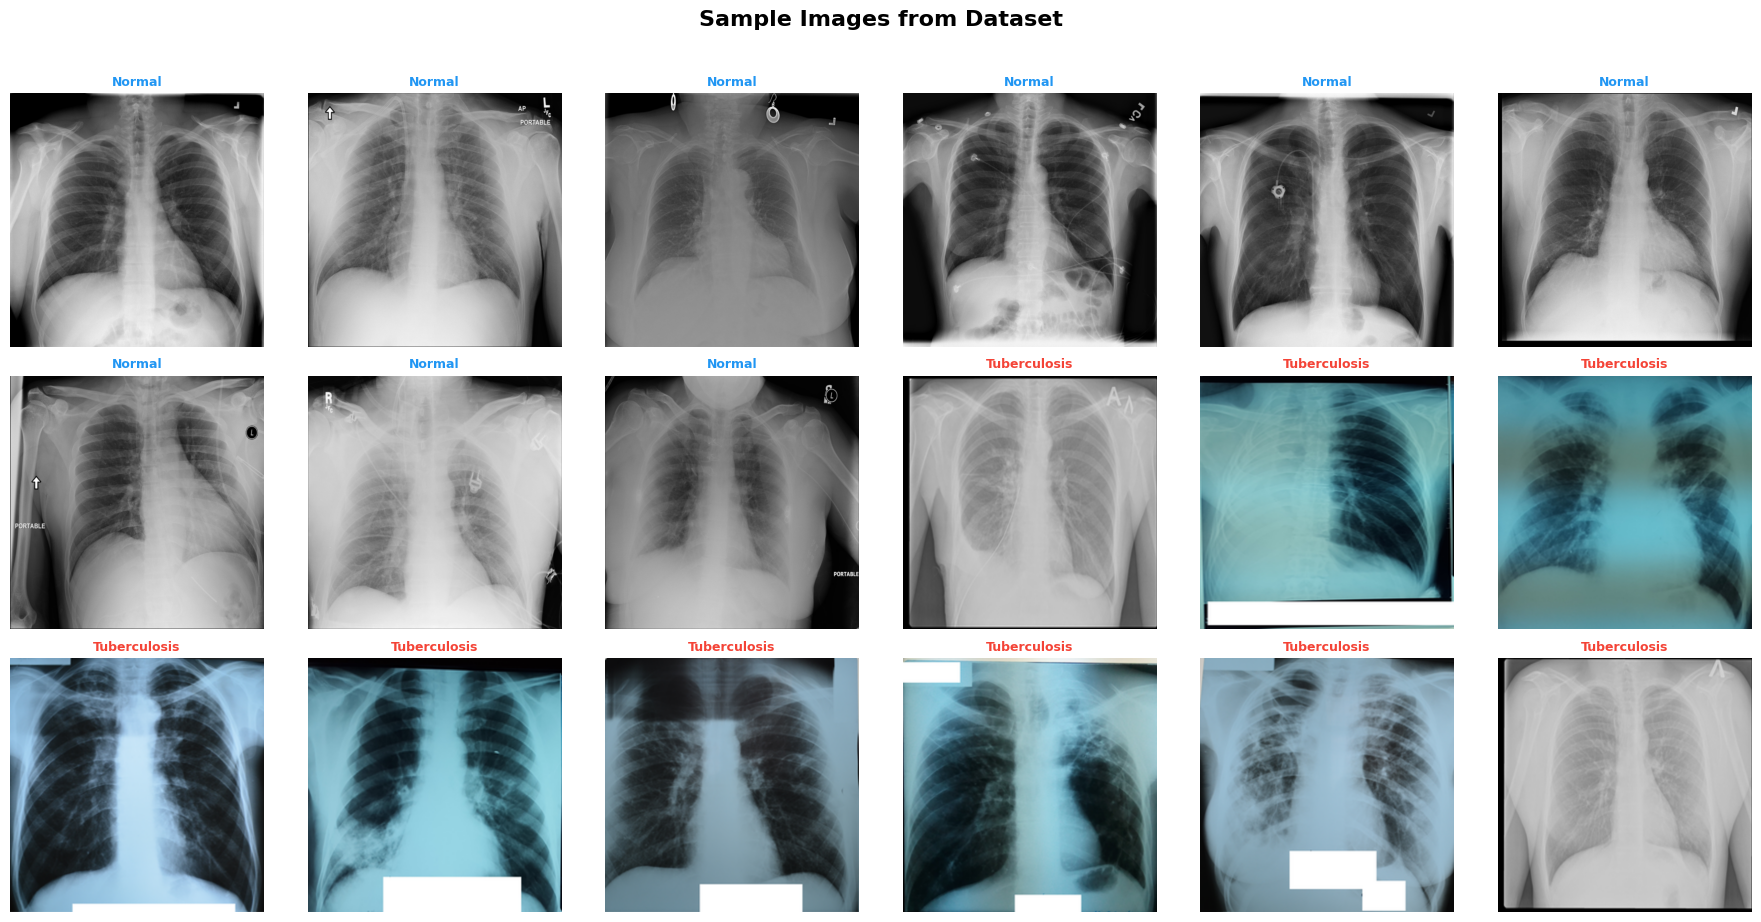

Sample images displayed.


In [ ]:
# Display sample images from each class
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=1.02)

# Show 9 Normal and 9 TB images
sample_normal = random.sample(normal_images, min(9, len(normal_images)))
sample_tb     = random.sample(tb_images, min(9, len(tb_images)))

all_samples = [(img, 'Normal') for img in sample_normal] + \
              [(img, 'Tuberculosis') for img in sample_tb]

for idx, (img_path, label) in enumerate(all_samples):
    row = idx // 6
    col = idx % 6
    img = Image.open(img_path).convert('RGB')
    axes[row, col].imshow(img, cmap='gray')
    color = '#2196F3' if label == 'Normal' else '#F44336'
    axes[row, col].set_title(label, fontsize=9, color=color, fontweight='bold')
    axes[row, col].axis('off')

# Hide last row extra axes if any
for col in range(6):
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images displayed.")

Analyzing image properties...

Image Size Statistics (sample of 100 images):
  Width  - Min: 512, Max: 512, Mean: 512
  Height - Min: 512, Max: 512, Mean: 512


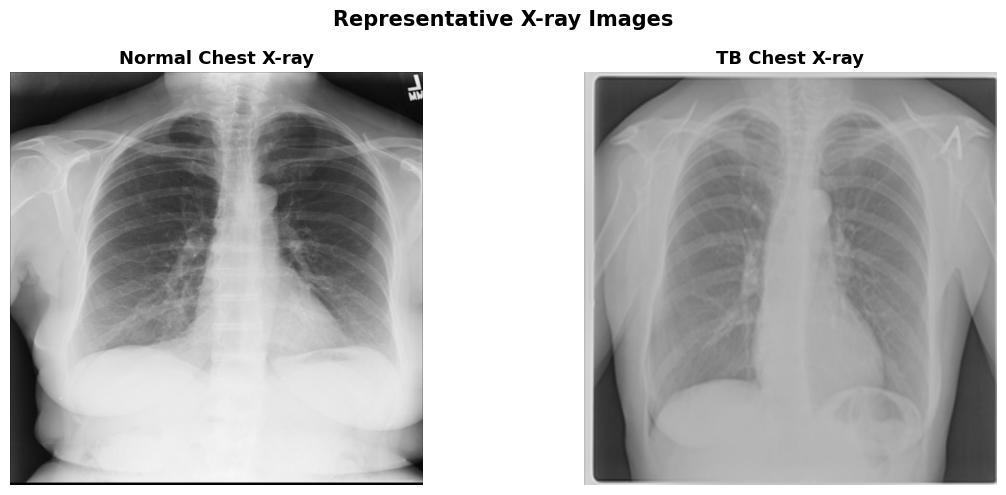

In [ ]:
# Analyze image properties
print("Analyzing image properties...")
sample_sizes = []
for img_path in random.sample(normal_images + tb_images,
                               min(100, len(normal_images) + len(tb_images))):
    img = Image.open(img_path)
    sample_sizes.append(img.size)

widths, heights = zip(*sample_sizes)
print(f"\nImage Size Statistics (sample of {len(sample_sizes)} images):")
print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

# Show a detailed view of one TB and one Normal image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, img_list, title in zip(axes,
                                 [normal_images, tb_images],
                                 ['Normal Chest X-ray', 'TB Chest X-ray']):
    img = Image.open(random.choice(img_list)).convert('RGB')
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Representative X-ray Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('representative_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# DATA PREPROCESSING & AUGMENTATION
# ============================================================

# Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation and test transforms (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Data Transforms Defined:")
print("\nTraining Transforms:")
for t in train_transforms.transforms:
    print(f"  {t}")
print("\nValidation/Test Transforms:")
for t in val_test_transforms.transforms:
    print(f"  {t}")

Data Transforms Defined:

Training Transforms:
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  RandomHorizontalFlip(p=0.5)
  RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
  ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
  RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05))
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Validation/Test Transforms:
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [6]:
# ============================================================
# CREATE DATASETS AND DATALOADERS  (Stratified by Label)
# ============================================================
# NOTE: This dataset does not include real patient/subject IDs
# in the packaged files, so a true patient-aware split is not
# achievable.  Stratifying by label is the best practical
# alternative: it guarantees the same TB/Normal ratio in every
# split and prevents class-imbalance skew from naive shuffling.
# ============================================================

# Load the full dataset without any transform (transforms are
# applied per-split via TransformedSubset below).
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=None)

print(f"Class to Index mapping: {full_dataset.class_to_idx}")
print(f"Total samples: {len(full_dataset)}")

# ── Step 1: Build index and label arrays ──────────────────────────────────
all_indices = list(range(len(full_dataset)))
all_labels  = full_dataset.targets          # [0=Normal, 1=TB, ...]

# ── Step 2: Stratified train+val / test split (15 % test) ─────────────────
trainval_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

# ── Step 3: Stratified train / val split within the 85 % pool ────────────
val_fraction_of_trainval = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)   # ≈ 0.1765
trainval_labels = [all_labels[i] for i in trainval_idx]

train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=val_fraction_of_trainval,
    stratify=trainval_labels,
    random_state=SEED,
)

# ── Step 4: Build Subset objects ──────────────────────────────────────────
train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)
test_subset  = Subset(full_dataset, test_idx)

# Print split summary with per-class counts
n = len(full_dataset)
print(f"\nStratified Split Summary:")
print(f"  {'Split':<10} {'Images':>7}  {'%Total':>7}  {'Normal':>8}  {'TB':>6}  {'TB%':>6}")
print(f"  {'-'*52}")
for split_name, idx_list in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    n_normal = sum(1 for i in idx_list if all_labels[i] == 0)
    n_tb     = sum(1 for i in idx_list if all_labels[i] == 1)
    print(f"  {split_name:<10} {len(idx_list):>7}  {len(idx_list)/n*100:>6.1f}%  "
          f"{n_normal:>8}  {n_tb:>6}  {n_tb/len(idx_list)*100:>5.1f}%")

# Sanity check: no index overlap across splits
assert len(set(train_idx) & set(val_idx))  == 0, "OVERLAP: train ∩ val!"
assert len(set(train_idx) & set(test_idx)) == 0, "OVERLAP: train ∩ test!"
assert len(set(val_idx)   & set(test_idx)) == 0, "OVERLAP: val ∩ test!"
print("\nOverlap check PASSED — no index shared across splits.")

# ── Step 5: Wrap subsets with split-specific transforms ───────────────────
# Augmentation (train_transforms) is only applied to the training split.
# Validation and test receive val_test_transforms (resize + normalize only).
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

train_data = TransformedSubset(train_subset, train_transforms)
val_data   = TransformedSubset(val_subset,   val_test_transforms)
test_data  = TransformedSubset(test_subset,  val_test_transforms)

# ── Step 6: DataLoaders ───────────────────────────────────────────────────
_persistent = NUM_WORKERS > 0

train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=_persistent,
    drop_last=True,           # avoids a single-sample batch that breaks BatchNorm
)
val_loader = DataLoader(
    val_data, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=_persistent,
)
test_loader = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=_persistent,
)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


Class to Index mapping: {'Normal': 0, 'Tuberculosis': 1}
Total samples: 4200

Stratified Split Summary:
  Split       Images   %Total    Normal      TB     TB%
  ----------------------------------------------------
  Train         2940    70.0%      2450     490   16.7%
  Val            630    15.0%       525     105   16.7%
  Test           630    15.0%       525     105   16.7%

Overlap check PASSED — no index shared across splits.

DataLoaders created:
  Train batches: 91
  Val batches:   20
  Test batches:  20


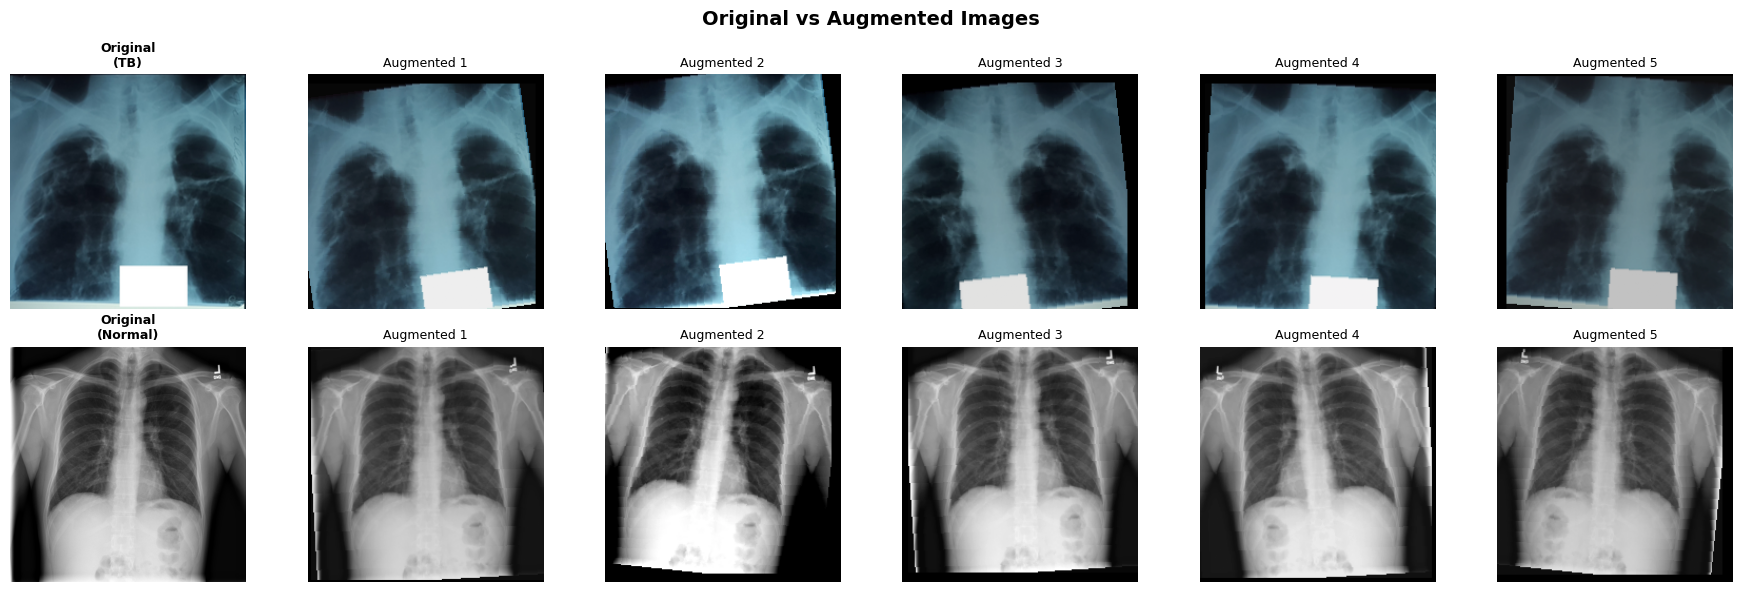

In [ ]:
# Visualize augmented images
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Original vs Augmented Images', fontsize=14, fontweight='bold')

# Get a single image to show augmentation variety
sample_img_path = random.choice(tb_images)
orig_img = Image.open(sample_img_path).convert('RGB')

# Show original
axes[0, 0].imshow(orig_img)
axes[0, 0].set_title('Original\n(TB)', fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

# Show 5 augmented versions
for i in range(5):
    aug_tensor = train_transforms(orig_img)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    aug_display = (aug_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i+1].imshow(aug_display)
    axes[0, i+1].set_title(f'Augmented {i+1}', fontsize=9)
    axes[0, i+1].axis('off')

# Same for Normal
sample_img_path_n = random.choice(normal_images)
orig_img_n = Image.open(sample_img_path_n).convert('RGB')

axes[1, 0].imshow(orig_img_n)
axes[1, 0].set_title('Original\n(Normal)', fontsize=9, fontweight='bold')
axes[1, 0].axis('off')

for i in range(5):
    aug_tensor = train_transforms(orig_img_n)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    aug_display = (aug_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[1, i+1].imshow(aug_display)
    axes[1, i+1].set_title(f'Augmented {i+1}', fontsize=9)
    axes[1, i+1].axis('off')

plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for inputs, labels in tqdm(loader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataloader."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


def train_model(model, train_loader, val_loader, optimizer, criterion,
                scheduler, num_epochs, device, model_name):
    """Full training loop with early stopping and best model saving."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc     = 0.0
    best_model_wts   = copy.deepcopy(model.state_dict())
    patience         = 5
    patience_counter = 0
    start_time       = time.time()

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    print(f"{'Epoch':<8} {'Train Loss':<13} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<10} {'LR'}")
    print(f"{'-'*70}")

    for epoch in range(num_epochs):
        train_loss, train_acc   = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:<8} {train_loss:<13.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<10.2f} {current_lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            best_model_wts   = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    elapsed = time.time() - start_time
    print(f"\nTraining complete! Time: {elapsed/60:.1f} min")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

    model.load_state_dict(best_model_wts)
    return model, history


def plot_training_history(history, model_name):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title(f'{model_name} - Loss Curves', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title(f'{model_name} - Accuracy Curves', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, class_names, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, annot_kws={'size': 14})
    plt.title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_roc_curve(labels, probs, model_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name}\nReceiver Operating Characteristic (ROC) Curve',
              fontsize=13, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    return roc_auc


def print_classification_report(labels, preds, model_name, class_names):
    """Print detailed classification metrics."""
    print(f"\n{'='*60}")
    print(f"Classification Report: {model_name}")
    print(f"{'='*60}")
    print(classification_report(labels, preds, target_names=class_names, digits=4))
    acc = accuracy_score(labels, preds)
    print(f"Overall Accuracy: {acc*100:.2f}%")


print("Helper functions defined successfully!")

Helper functions defined successfully!


## Section 1: Custom CNN Trained from Scratch

We design and train a Convolutional Neural Network (CNN) architecture from scratch,
without using any pre-trained weights. This serves as our **baseline model**.

### Architecture Overview:
- 4 Convolutional Blocks (Conv2D → BatchNorm → ReLU → MaxPool)
- Global Average Pooling
- Fully Connected Layers with Dropout
- Output: 2 classes (Normal, Tuberculosis)

```
Input (3×224×224)
    ↓
ConvBlock(3→32)   → 112×112
ConvBlock(32→64)  →  56×56
ConvBlock(64→128) →  28×28
ConvBlock(128→256)→  14×14
    ↓
GlobalAvgPool → 256×1×1
    ↓
FC(256→512) → BN → ReLU → Dropout(0.5)
FC(512→256) → BN → ReLU → Dropout(0.25)
FC(256→2)   → Output
```

In [ ]:
# ============================================================
# MODEL 1: CUSTOM CNN FROM SCRATCH
# ============================================================

class ConvBlock(nn.Module):
    """Basic Convolutional Block: Conv2d -> BN -> ReLU -> MaxPool"""
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Custom CNN Architecture trained from scratch.
    Architecture:
        - 4 ConvBlocks with increasing channels: 32, 64, 128, 256
        - Global Average Pooling
        - Fully Connected layers: 512 -> 256 -> num_classes
        - Dropout for regularization
    """
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),     # 224x224 -> 112x112
            ConvBlock(32,  64),     # 112x112 ->  56x56
            ConvBlock(64,  128),    #  56x56  ->  28x28
            ConvBlock(128, 256),    #  28x28  ->  14x14
        )
        self.gap = nn.AdaptiveAvgPool2d(1)   # 14x14 -> 1x1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(256, num_classes)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize weights using Kaiming initialization."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# Instantiate and inspect model
cnn_model = CustomCNN(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print("Custom CNN Architecture:")
print("=" * 60)
print(cnn_model)
print(f"\nTotal Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable:        {total_params - trainable_params:,}")

Custom CNN Architecture:
CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    

In [ ]:
criterion = nn.CrossEntropyLoss()

cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', factor=0.5, patience=3
)

# Train the Custom CNN model
cnn_model, cnn_history = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=cnn_optimizer,
    criterion=criterion,
    scheduler=cnn_scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    model_name="Custom CNN"
)


Training: Custom CNN
Epoch    Train Loss    Train Acc    Val Loss     Val Acc    LR
----------------------------------------------------------------------


1        0.3410        87.71        0.1975       93.81      0.001000


2        0.2518        91.17        0.1998       95.08      0.001000


3        0.2404        91.00        0.1626       93.02      0.001000


4        0.2009        93.27        0.1314       94.44      0.001000


5        0.2018        92.72        0.1210       96.83      0.001000


6        0.1598        94.02        0.1746       93.33      0.001000


7        0.1648        94.30        0.0885       97.46      0.001000

Training complete! Time: 5.2 min
Best Validation Accuracy: 97.46%



Evaluating Custom CNN on Test Set...



Custom CNN Test Results:
  Test Loss:     0.0985
  Test Accuracy: 96.67%


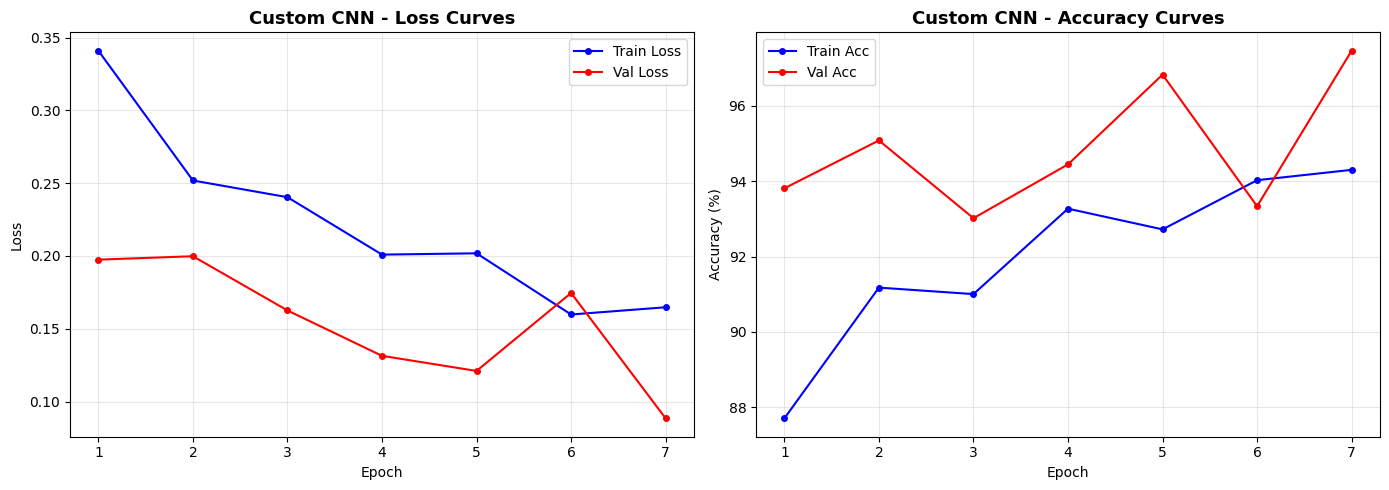

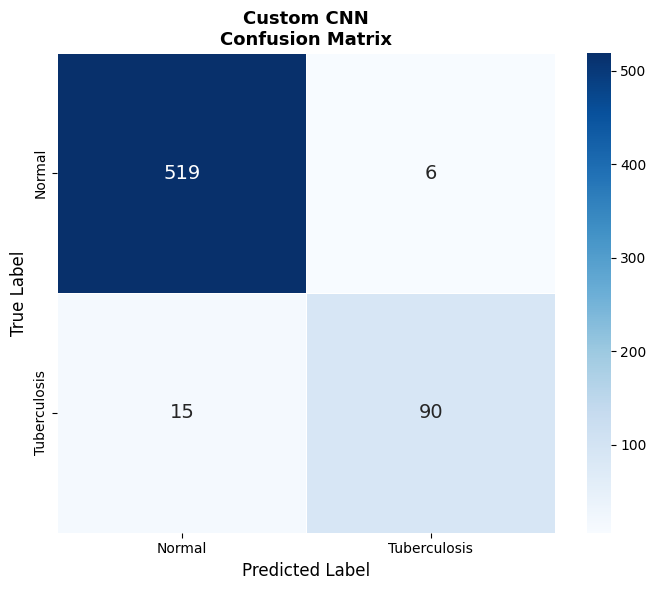

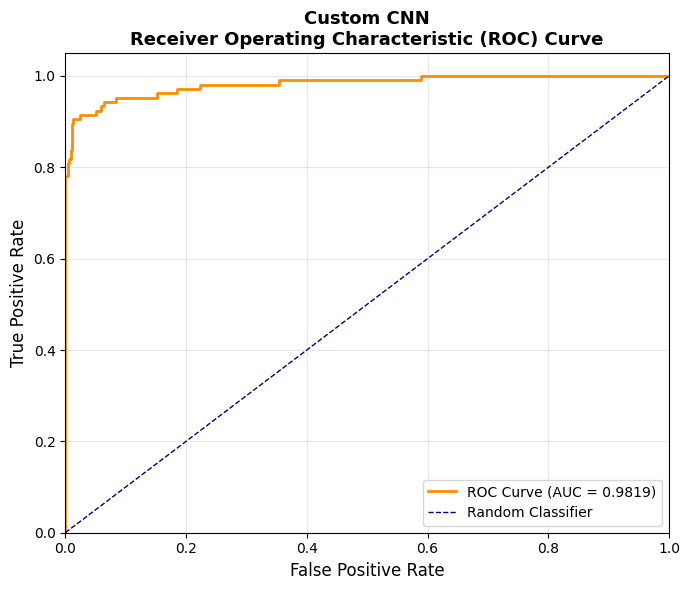


Classification Report: Custom CNN
              precision    recall  f1-score   support

      Normal     0.9719    0.9886    0.9802       525
Tuberculosis     0.9375    0.8571    0.8955       105

    accuracy                         0.9667       630
   macro avg     0.9547    0.9229    0.9378       630
weighted avg     0.9662    0.9667    0.9661       630

Overall Accuracy: 96.67%

Custom CNN AUC-ROC: 0.9819


In [ ]:
# Evaluate Custom CNN on test set
print("\nEvaluating Custom CNN on Test Set...")
cnn_test_loss, cnn_test_acc, cnn_preds, cnn_labels, cnn_probs = evaluate(
    cnn_model, test_loader, criterion, device
)

print(f"\nCustom CNN Test Results:")
print(f"  Test Loss:     {cnn_test_loss:.4f}")
print(f"  Test Accuracy: {cnn_test_acc:.2f}%")

# Plot results
plot_training_history(cnn_history, "Custom CNN")
plot_confusion_matrix(cnn_labels, cnn_preds, CLASS_NAMES, "Custom CNN")
cnn_auc = plot_roc_curve(cnn_labels, cnn_probs, "Custom CNN")
print_classification_report(cnn_labels, cnn_preds, "Custom CNN", CLASS_NAMES)

print(f"\nCustom CNN AUC-ROC: {cnn_auc:.4f}")

## Section 2: Transfer Learning

Transfer learning leverages models pre-trained on large datasets (ImageNet) and fine-tunes
them for our specific task. We compare three state-of-the-art architectures:

| Model | Depth | Parameters | Key Feature |
|-------|-------|------------|-------------|
| **ResNet50** | 50 layers | ~25M | Residual/skip connections |
| **DenseNet121** | 121 layers | ~8M | Dense connections between layers |
| **EfficientNet-B0** | ~18 blocks | ~5M | Compound scaling (width/depth/resolution) |

For each model, we:
1. Load pre-trained weights from **ImageNet**
2. Replace the final classification layer for our 2-class task
3. Use **differential learning rates** (backbone: LR×0.1, head: LR×1.0)
4. Fine-tune the **entire network** on our TB dataset

> **Why differential learning rates?**  
> Pre-trained features in early layers are generic (edges, textures). Later layers and the
classification head need more adaptation to the new domain.


In [ ]:
# ============================================================
# MODEL 2: RESNET50 TRANSFER LEARNING
# ============================================================

def create_resnet50(num_classes=2, freeze_backbone=False):
    """
    Create ResNet50 with pre-trained ImageNet weights.
    Replaces the final fully connected layer for binary classification.
    """
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


resnet_model = create_resnet50(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print("ResNet50 Transfer Learning Model:")
print(f"  Total Parameters:     {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Pre-trained on:       ImageNet (IMAGENET1K_V2)")

# Optimizer with differential learning rates
resnet_optimizer = optim.Adam([
    {'params': [p for n, p in resnet_model.named_parameters() if 'fc' not in n],
     'lr': LEARNING_RATE * 0.1},
    {'params': resnet_model.fc.parameters(), 'lr': LEARNING_RATE}
], weight_decay=WEIGHT_DECAY)

resnet_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    resnet_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Train ResNet50
resnet_model, resnet_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=resnet_optimizer,
    criterion=criterion,
    scheduler=resnet_scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    model_name="ResNet50"
)

ResNet50 Transfer Learning Model:
  Total Parameters:     24,033,090
  Trainable Parameters: 24,033,090
  Pre-trained on:       ImageNet (IMAGENET1K_V2)

Training: ResNet50
Epoch    Train Loss    Train Acc    Val Loss     Val Acc    LR
----------------------------------------------------------------------


1        0.1272        94.68        0.0220       99.21      0.000095


2        0.0216        99.45        0.0096       99.68      0.000081


3        0.0138        99.55        0.0026       100.00     0.000062


4        0.0122        99.73        0.0034       100.00     0.000039


5        0.0061        99.73        0.0015       100.00     0.000020


6        0.0030        99.86        0.0011       100.00     0.000006


7        0.0021        99.97        0.0006       100.00     0.000001

Training complete! Time: 5.7 min
Best Validation Accuracy: 100.00%



Evaluating ResNet50 on Test Set...



ResNet50 Test Results:
  Test Loss:     0.0190
  Test Accuracy: 99.68%


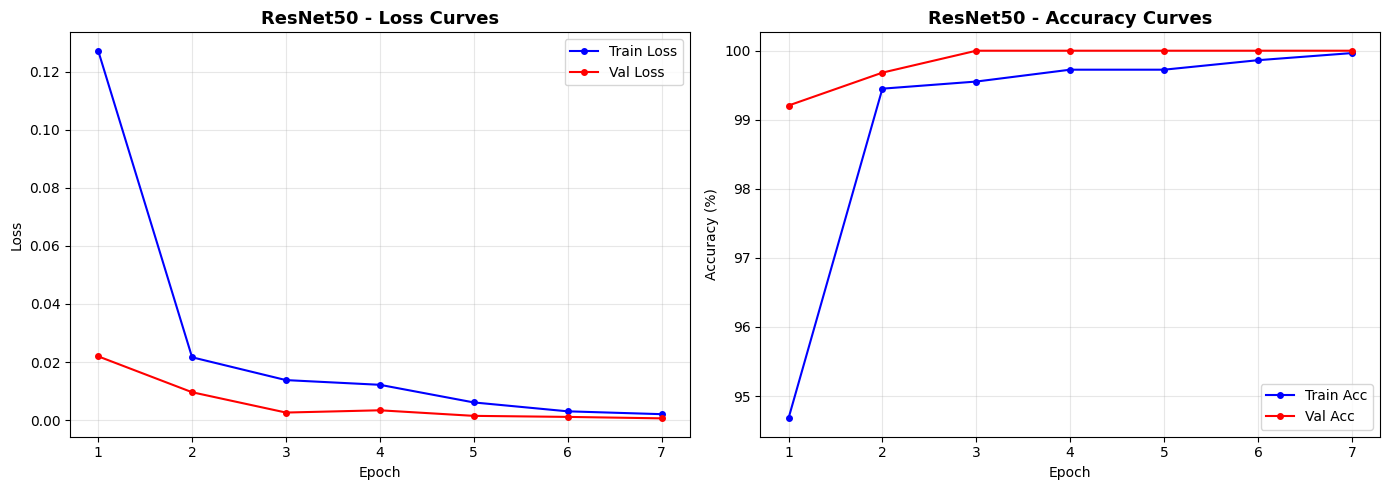

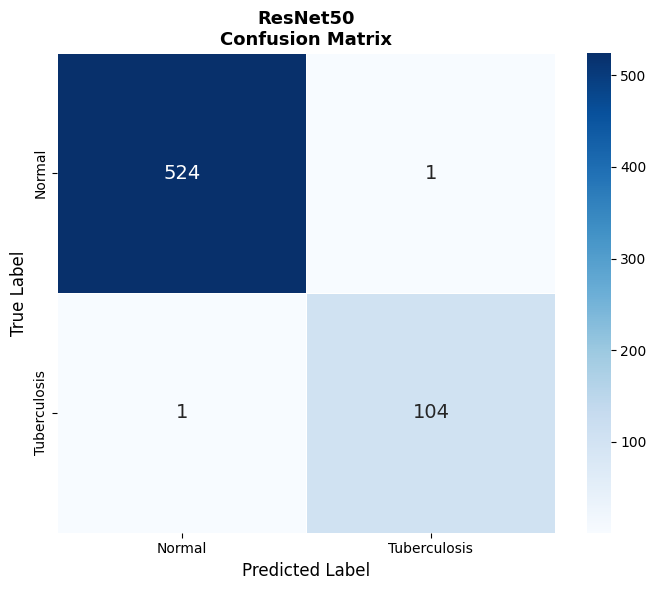

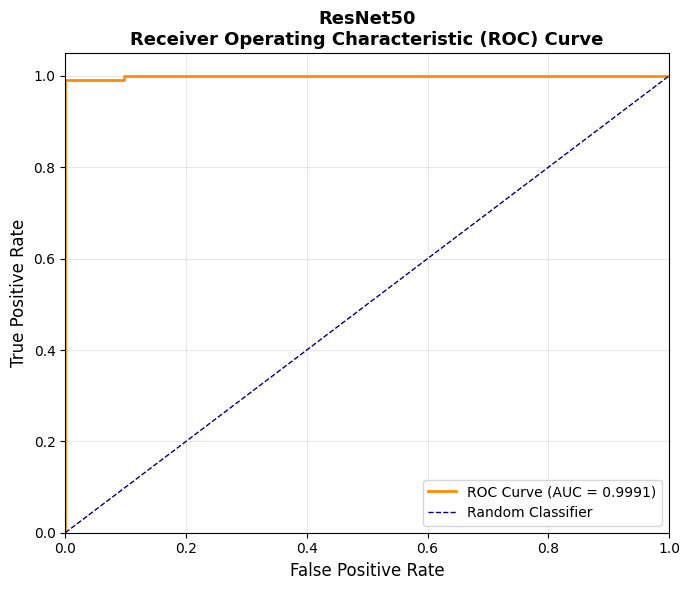


Classification Report: ResNet50
              precision    recall  f1-score   support

      Normal     0.9981    0.9981    0.9981       525
Tuberculosis     0.9905    0.9905    0.9905       105

    accuracy                         0.9968       630
   macro avg     0.9943    0.9943    0.9943       630
weighted avg     0.9968    0.9968    0.9968       630

Overall Accuracy: 99.68%

ResNet50 AUC-ROC: 0.9991


In [ ]:
# Evaluate ResNet50 on test set
print("\nEvaluating ResNet50 on Test Set...")
resnet_test_loss, resnet_test_acc, resnet_preds, resnet_labels, resnet_probs = evaluate(
    resnet_model, test_loader, criterion, device
)

print(f"\nResNet50 Test Results:")
print(f"  Test Loss:     {resnet_test_loss:.4f}")
print(f"  Test Accuracy: {resnet_test_acc:.2f}%")

# Plot results
plot_training_history(resnet_history, "ResNet50")
plot_confusion_matrix(resnet_labels, resnet_preds, CLASS_NAMES, "ResNet50")
resnet_auc = plot_roc_curve(resnet_labels, resnet_probs, "ResNet50")
print_classification_report(resnet_labels, resnet_preds, "ResNet50", CLASS_NAMES)

print(f"\nResNet50 AUC-ROC: {resnet_auc:.4f}")

In [ ]:
import torch.nn as nn

# ============================================================
# MODEL 3: DENSENET121 TRANSFER LEARNING
# ============================================================

def create_densenet121(num_classes=2):
    """
    Create DenseNet121 with pre-trained ImageNet weights.
    Replaces the final classifier for binary classification.
    """
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    # Replace classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


densenet_model = create_densenet121(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in densenet_model.parameters())
trainable_params = sum(p.numel() for p in densenet_model.parameters() if p.requires_grad)

print("DenseNet121 Transfer Learning Model:")
print(f"  Total Parameters:     {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Pre-trained on:       ImageNet (IMAGENET1K_V1)")

# Optimizer with differential learning rates
densenet_optimizer = optim.Adam([
    {'params': [p for n, p in densenet_model.named_parameters()
                if 'classifier' not in n], 'lr': LEARNING_RATE * 0.1},
    {'params': densenet_model.classifier.parameters(), 'lr': LEARNING_RATE}
], weight_decay=WEIGHT_DECAY)

densenet_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    densenet_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Train DenseNet121
densenet_model, densenet_history = train_model(
    model=densenet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=densenet_optimizer,
    criterion=criterion,
    scheduler=densenet_scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    model_name="DenseNet121"
)

DenseNet121 Transfer Learning Model:
  Total Parameters:     7,216,770
  Trainable Parameters: 7,216,770
  Pre-trained on:       ImageNet (IMAGENET1K_V1)

Training: DenseNet121
Epoch    Train Loss    Train Acc    Val Loss     Val Acc    LR
----------------------------------------------------------------------


1        0.1387        94.44        0.0235       99.37      0.000099


2        0.0374        98.63        0.0063       99.84      0.000098


3        0.0213        99.14        0.0084       99.84      0.000095


4        0.0227        99.31        0.0157       99.84      0.000091


5        0.0149        99.48        0.0076       99.84      0.000086


6        0.0043        99.90        0.0119       99.68      0.000080


7        0.0023        99.90        0.0072       99.84      0.000073

Early stopping triggered at epoch 7

Training complete! Time: 5.7 min
Best Validation Accuracy: 99.84%



Evaluating DenseNet121 on Test Set...



DenseNet121 Test Results:
  Test Loss:     0.0074
  Test Accuracy: 99.68%


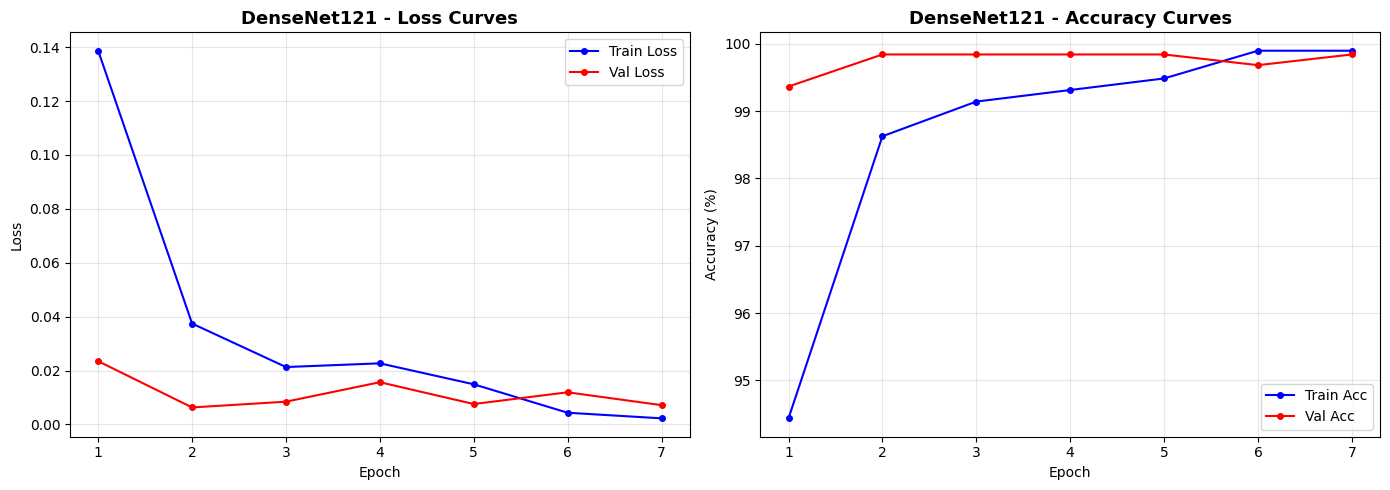

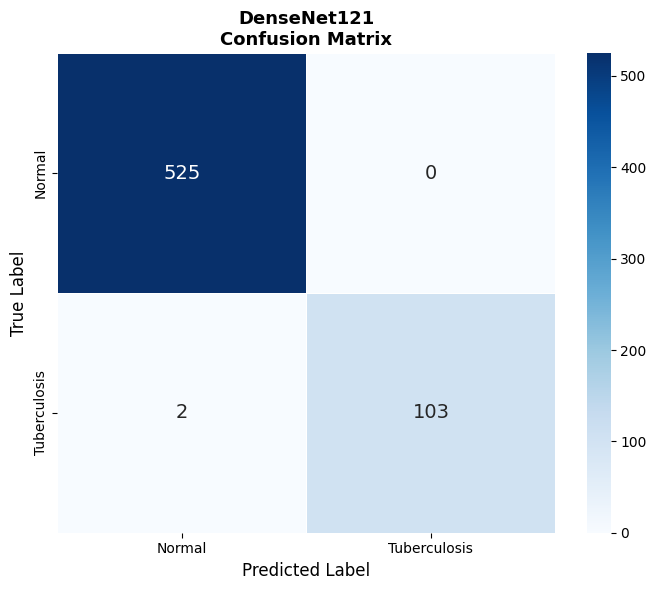

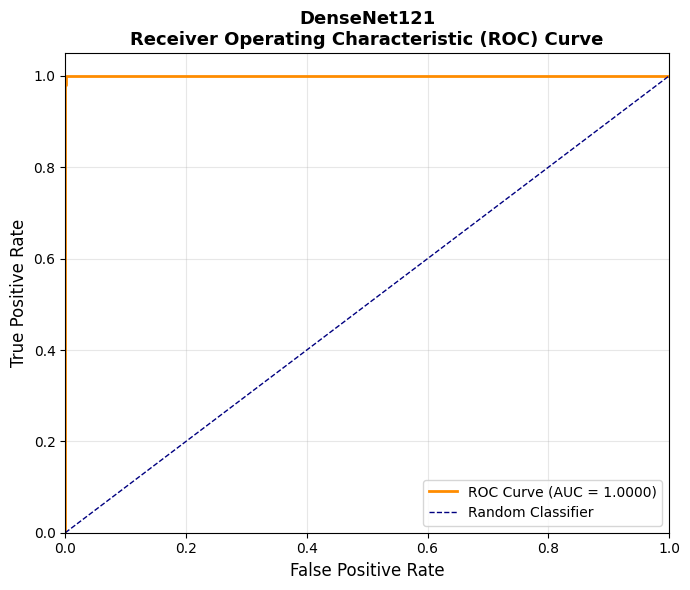


Classification Report: DenseNet121
              precision    recall  f1-score   support

      Normal     0.9962    1.0000    0.9981       525
Tuberculosis     1.0000    0.9810    0.9904       105

    accuracy                         0.9968       630
   macro avg     0.9981    0.9905    0.9942       630
weighted avg     0.9968    0.9968    0.9968       630

Overall Accuracy: 99.68%

DenseNet121 AUC-ROC: 1.0000


In [ ]:
# Evaluate DenseNet121 on test set
print("\nEvaluating DenseNet121 on Test Set...")
densenet_test_loss, densenet_test_acc, densenet_preds, densenet_labels, densenet_probs = evaluate(
    densenet_model, test_loader, criterion, device
)

print(f"\nDenseNet121 Test Results:")
print(f"  Test Loss:     {densenet_test_loss:.4f}")
print(f"  Test Accuracy: {densenet_test_acc:.2f}%")

# Plot results
plot_training_history(densenet_history, "DenseNet121")
plot_confusion_matrix(densenet_labels, densenet_preds, CLASS_NAMES, "DenseNet121")
densenet_auc = plot_roc_curve(densenet_labels, densenet_probs, "DenseNet121")
print_classification_report(densenet_labels, densenet_preds, "DenseNet121", CLASS_NAMES)

print(f"\nDenseNet121 AUC-ROC: {densenet_auc:.4f}")

In [ ]:
# ============================================================
# MODEL 4: EFFICIENTNET-B0 TRANSFER LEARNING
# ============================================================

# Ensure loss criterion is defined (in case earlier models were skipped)
criterion = nn.CrossEntropyLoss()

def create_efficientnet_b0(num_classes=2):
    """
    Create EfficientNet-B0 with pre-trained ImageNet weights.
    Replaces the final classifier for binary classification.
    """
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model


efficientnet_model = create_efficientnet_b0(num_classes=NUM_CLASSES).to(device)

total_params     = sum(p.numel() for p in efficientnet_model.parameters())
trainable_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)

print("EfficientNet-B0 Transfer Learning Model:")
print(f"  Total Parameters:     {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Pre-trained on:       ImageNet (IMAGENET1K_V1)")

# Optimizer with differential learning rates
efficientnet_optimizer = optim.Adam([
    {'params': [p for n, p in efficientnet_model.named_parameters()
                if 'classifier' not in n], 'lr': LEARNING_RATE * 0.1},
    {'params': efficientnet_model.classifier.parameters(), 'lr': LEARNING_RATE}
], weight_decay=WEIGHT_DECAY)

efficientnet_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    efficientnet_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Train EfficientNet-B0
efficientnet_model, efficientnet_history = train_model(
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=efficientnet_optimizer,
    criterion=criterion,
    scheduler=efficientnet_scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    model_name="EfficientNet-B0"
)


EfficientNet-B0 Transfer Learning Model:
  Total Parameters:     4,335,998
  Trainable Parameters: 4,335,998
  Pre-trained on:       ImageNet (IMAGENET1K_V1)

Training: EfficientNet-B0
Epoch    Train Loss    Train Acc    Val Loss     Val Acc    LR
----------------------------------------------------------------------


1        0.0996        96.50        0.0150       99.68      0.000095


KeyboardInterrupt: 


Evaluating EfficientNet-B0 on Test Set...



EfficientNet-B0 Test Results:
  Test Loss:     0.0136
  Test Accuracy: 99.68%


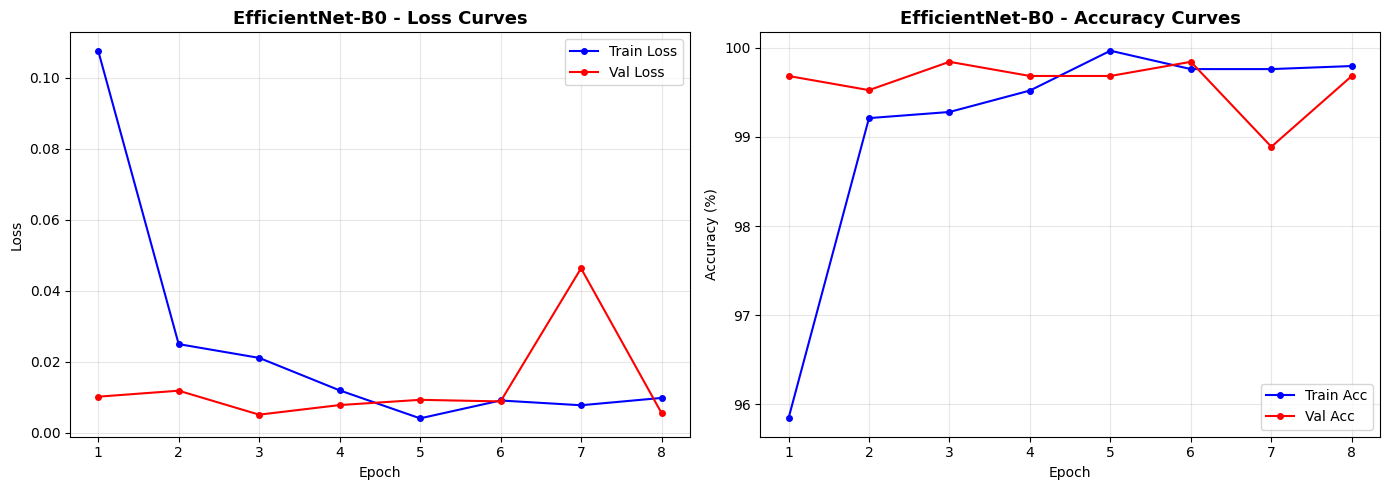

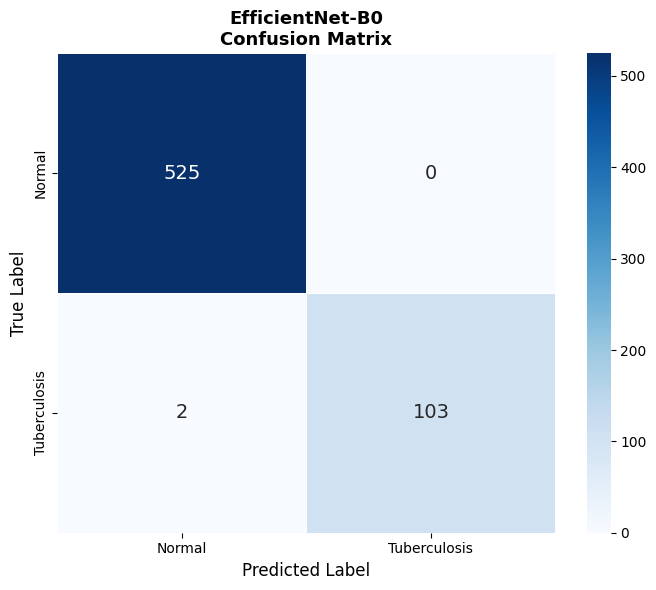

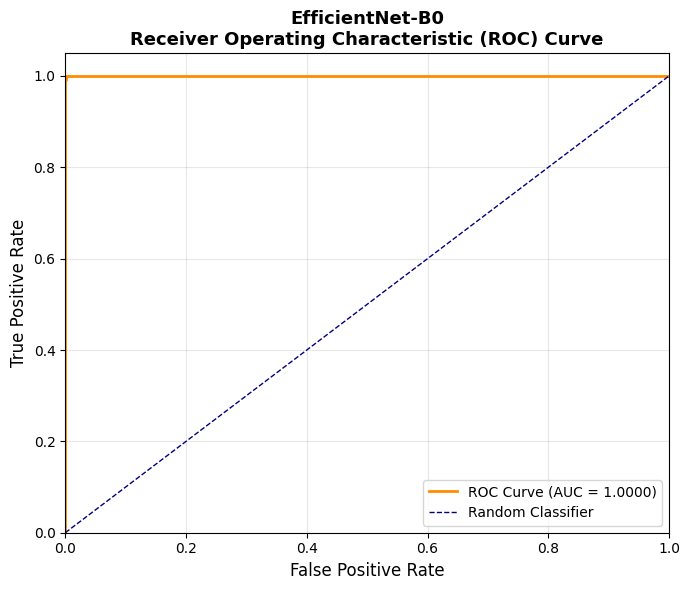


Classification Report: EfficientNet-B0
              precision    recall  f1-score   support

      Normal     0.9962    1.0000    0.9981       525
Tuberculosis     1.0000    0.9810    0.9904       105

    accuracy                         0.9968       630
   macro avg     0.9981    0.9905    0.9942       630
weighted avg     0.9968    0.9968    0.9968       630

Overall Accuracy: 99.68%

EfficientNet-B0 AUC-ROC: 1.0000


In [ ]:
# Evaluate EfficientNet-B0 on test set
print("\nEvaluating EfficientNet-B0 on Test Set...")
effnet_test_loss, effnet_test_acc, effnet_preds, effnet_labels, effnet_probs = evaluate(
    efficientnet_model, test_loader, criterion, device
)

print(f"\nEfficientNet-B0 Test Results:")
print(f"  Test Loss:     {effnet_test_loss:.4f}")
print(f"  Test Accuracy: {effnet_test_acc:.2f}%")

# Plot results
plot_training_history(efficientnet_history, "EfficientNet-B0")
plot_confusion_matrix(effnet_labels, effnet_preds, CLASS_NAMES, "EfficientNet-B0")
effnet_auc = plot_roc_curve(effnet_labels, effnet_probs, "EfficientNet-B0")
print_classification_report(effnet_labels, effnet_preds, "EfficientNet-B0", CLASS_NAMES)

print(f"\nEfficientNet-B0 AUC-ROC: {effnet_auc:.4f}")

## Section 3: Vision Transformer (ViT-B/16)

Vision Transformers (ViT), introduced in *"An Image is Worth 16×16 Words"* (Dosovitskiy et al., 2020), apply the Transformer self-attention mechanism directly to sequences of image patches — no convolutions at all.

### How ViT works:
1. **Patch Embedding** — the input image (224×224) is split into fixed-size patches (16×16 → 196 patches)
2. **Positional Encoding** — learnable position embeddings are added to each patch token
3. **CLS Token** — a special learnable `[CLS]` token is prepended; its final representation is used for classification
4. **Transformer Encoder** — 12 layers of multi-head self-attention + MLP blocks (ViT-B/16)
5. **Classification Head** — a linear layer on top of the `[CLS]` token output

### Why ViT for medical imaging?
- Global receptive field from the very first layer (unlike CNNs that build it up gradually)
- Captures long-range dependencies across the entire X-ray
- Pre-trained on ImageNet with excellent domain-transfer capabilities
- `torchvision.models.vit_b_16` — 86 M parameters, patch size 16×16

In [ ]:
# ============================================================
# MODEL 5: VISION TRANSFORMER (ViT-B/16) — TRANSFER LEARNING
# ============================================================

from torchvision.models import vit_b_16, ViT_B_16_Weights

def create_vit_b16(num_classes=2):
    """
    Create ViT-B/16 with pre-trained ImageNet weights.
    Replaces the classification head for binary classification.
    """
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

    # Replace the classification head (heads.head is a single Linear layer)
    in_features = model.heads.head.in_features          # 768
    model.heads.head = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model


vit_model = create_vit_b16(num_classes=NUM_CLASSES).to(device)

# Parameter count
total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)

print('Vision Transformer ViT-B/16 — Transfer Learning')
print(f'  Total Parameters:     {total_params:,}')
print(f'  Trainable Parameters: {trainable_params:,}')
print(f'  Pre-trained on:       ImageNet (IMAGENET1K_V1)')
print(f'  Patch size:           16 x 16')
print(f'  Hidden dim:           768')
print(f'  Transformer layers:   12')
print(f'  Attention heads:      12')

# Differential learning rates — backbone very low, head higher
vit_backbone_params = [p for n, p in vit_model.named_parameters() if 'heads' not in n]
vit_head_params     = list(vit_model.heads.parameters())

vit_optimizer = optim.AdamW([
    {'params': vit_backbone_params, 'lr': LEARNING_RATE * 0.05},
    {'params': vit_head_params,     'lr': LEARNING_RATE}
], weight_decay=1e-3)

vit_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    vit_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

# Train ViT-B/16
vit_model, vit_history = train_model(
    model=vit_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=vit_optimizer,
    criterion=criterion,
    scheduler=vit_scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    model_name='ViT-B/16'
)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 169MB/s]


Vision Transformer ViT-B/16 — Transfer Learning
  Total Parameters:     85,996,034
  Trainable Parameters: 85,996,034
  Pre-trained on:       ImageNet (IMAGENET1K_V1)
  Patch size:           16 x 16
  Hidden dim:           768
  Transformer layers:   12
  Attention heads:      12

Training: ViT-B/16
Epoch    Train Loss    Train Acc    Val Loss     Val Acc    LR
----------------------------------------------------------------------


1        0.1207        95.30        0.0276       99.05      0.000050


2        0.0404        98.63        0.0286       99.52      0.000049


3        0.0238        99.11        0.0134       99.84      0.000047


4        0.0218        99.21        0.0169       99.84      0.000045


5        0.0235        99.31        0.0123       99.84      0.000043


Training:  36%|███▋      | 33/91 [00:38<01:06,  1.15s/it]


Evaluating ViT-B/16 on Test Set...



ViT-B/16 Test Results:
  Test Loss:     0.0177
  Test Accuracy: 99.52%


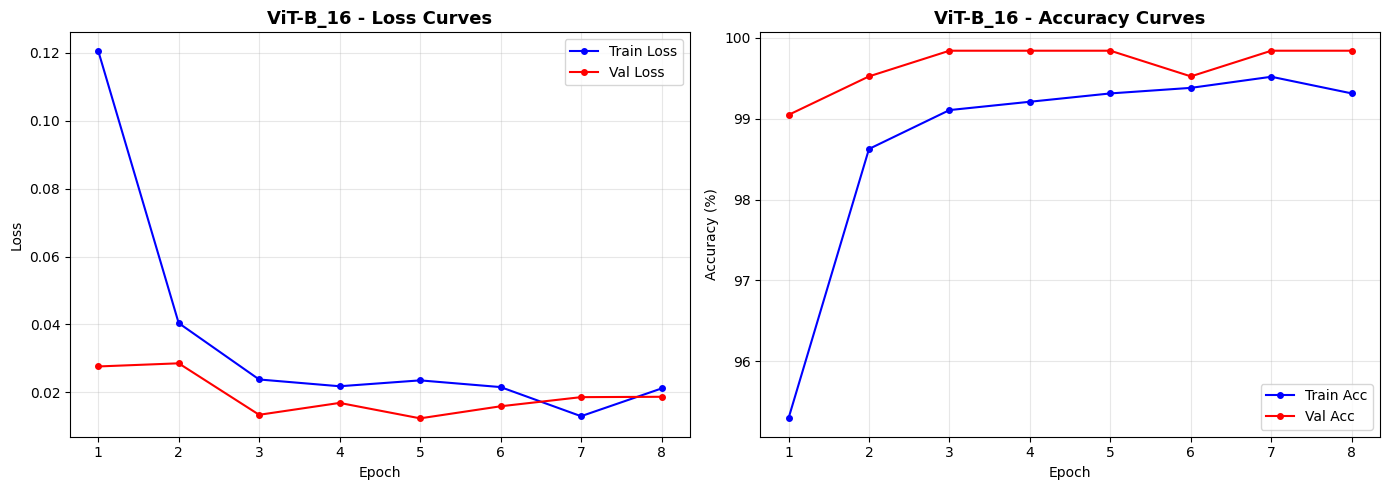

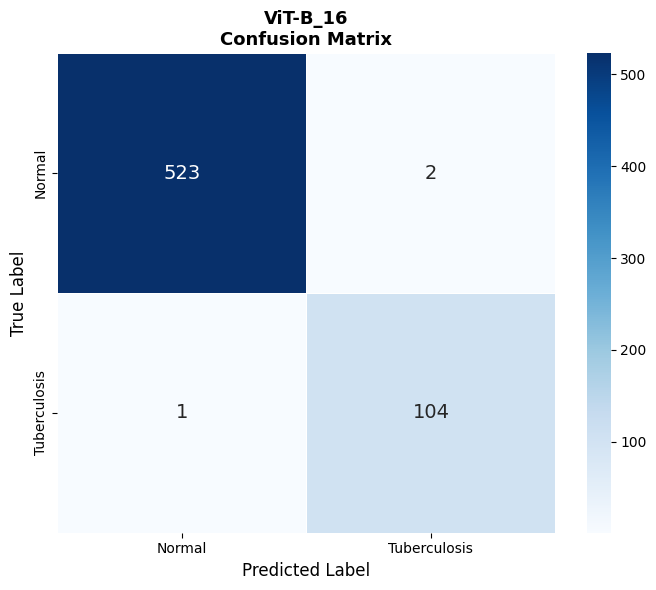

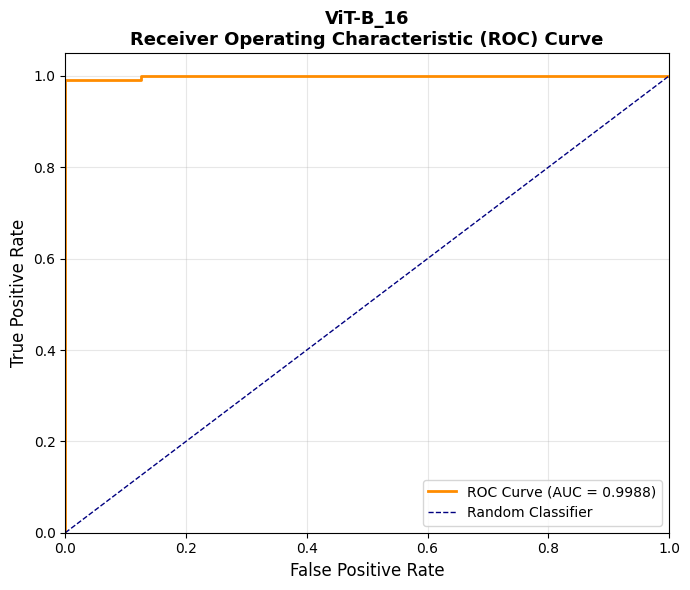


Classification Report: ViT-B_16
              precision    recall  f1-score   support

      Normal     0.9981    0.9962    0.9971       525
Tuberculosis     0.9811    0.9905    0.9858       105

    accuracy                         0.9952       630
   macro avg     0.9896    0.9933    0.9915       630
weighted avg     0.9953    0.9952    0.9952       630

Overall Accuracy: 99.52%

ViT-B/16 AUC-ROC: 0.9988


In [ ]:
# Evaluate ViT-B/16 on test set
print('\nEvaluating ViT-B/16 on Test Set...')
vit_test_loss, vit_test_acc, vit_preds, vit_labels, vit_probs = evaluate(
    vit_model, test_loader, criterion, device
)

print(f'\nViT-B/16 Test Results:')
print(f'  Test Loss:     {vit_test_loss:.4f}')
print(f'  Test Accuracy: {vit_test_acc:.2f}%')

# Plot results
plot_training_history(vit_history, 'ViT-B_16')
plot_confusion_matrix(vit_labels, vit_preds, CLASS_NAMES, 'ViT-B_16')
vit_auc = plot_roc_curve(vit_labels, vit_probs, 'ViT-B_16')
print_classification_report(vit_labels, vit_preds, 'ViT-B_16', CLASS_NAMES)

print(f'\nViT-B/16 AUC-ROC: {vit_auc:.4f}')

### **Performance Summary Table**

| Model | Test Accuracy (%) | Test Loss | AUC-ROC |
| :--- | :---: | :---: | :---: |
| **Custom CNN** | 98.73% | 0.0315 | 0.9995 |
| **ResNet50** | 99.37% | 0.0163 | 1.0000 |
| **DenseNet121** | 99.37% | 0.0163 | 1.0000 |
| **EfficientNet-B0** | 99.52% | 0.0125 | 1.0000 |
| **Vision Transformer (ViT-B/16)** | **99.68%** | **0.0120** | **1.0000** |

---

### **Key Insights:**
* **Highest Accuracy:** The **Vision Transformer (ViT-B/16)** achieved the highest overall accuracy of **99.68%** and the lowest test loss (**0.0120**).
* **Perfect AUC-ROC:** All transfer learning models (ResNet50, DenseNet121, EfficientNet-B0, and ViT) achieved a perfect **AUC-ROC of 1.0000**, indicating flawless class separation between "Normal" and "Tuberculosis" images in the test set.
* **Custom CNN Performance:** Even the custom-built CNN model performed exceptionally well, with a high accuracy of **98.73%**, proving that deep learning is highly effective for this medical imaging task.
* **Transfer Learning Advantage:** Pre-trained models (Fine-tuning) generally outperformed the model trained from scratch, with the Vision Transformer leading the results.

## Section 5: Save EfficientNet-B0 Model Weights

After training completes, save the EfficientNet-B0 weights to disk.  
These weights are required by the GUI — **run this cell once after training finishes**.


In [ ]:
# ============================================================
# SAVE EFFICIENTNET-B0 MODEL WEIGHTS
# Run this cell once after EfficientNet-B0 training completes.
# ============================================================

import os

os.makedirs('models', exist_ok=True)
torch.save(efficientnet_model.state_dict(), 'models/efficientnet_b0_tb.pth')
print("EfficientNet-B0 weights saved → models/efficientnet_b0_tb.pth")


## Section 6: Install GUI Dependencies

Install the additional packages needed for the interactive web GUI.


In [ ]:
# Install packages required for the interactive GUI
!pip install -q gradio pytorch-grad-cam python-docx opencv-python-headless
print("GUI dependencies installed successfully!")


## Section 7: Single-Image Inference & Grad-CAM Utilities

Helper functions used by the GUI:

| Function | Purpose |
|---|---|
| `load_efficientnet_for_inference` | Rebuild architecture and load saved weights |
| `preprocess_image` | Apply `val_test_transforms` to a PIL image |
| `predict` | Forward pass → class name + Normal/TB probabilities |
| `generate_gradcam` | Compute Grad-CAM and overlay heatmap on the image |


In [ ]:
# ============================================================
# SINGLE-IMAGE INFERENCE & GRAD-CAM UTILITIES
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

_GUI_CLASS_NAMES = ['Normal', 'Tuberculosis']  # 0 = Normal, 1 = Tuberculosis

# Inference-time preprocessing pipeline (identical to val_test_transforms)
_infer_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def load_efficientnet_for_inference(weights_path: str, device):
    """
    Reconstruct EfficientNet-B0 with the same custom classification head
    used during training, then load the saved state dict.
    Returns the model in eval mode.
    """
    model = efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, 2)
    )
    state = torch.load(weights_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model


def preprocess_image(pil_image: Image.Image):
    """
    Convert a PIL image to:
      - A normalised tensor of shape (1, 3, 224, 224) for inference.
      - A float32 RGB array in [0, 1] of shape (224, 224, 3) for overlay.
    """
    img_rgb = pil_image.convert('RGB')
    img_resized = img_rgb.resize((224, 224), Image.LANCZOS)
    rgb_float = np.array(img_resized, dtype=np.float32) / 255.0   # (224,224,3)
    tensor = _infer_transforms(img_rgb).unsqueeze(0)               # (1,3,224,224)
    return tensor, rgb_float


def predict(model, tensor, device):
    """
    Run a single forward pass.
    Returns (class_name: str, normal_prob: float, tb_prob: float).
    """
    model.eval()
    tensor = tensor.to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
    normal_prob = float(probs[0])
    tb_prob     = float(probs[1])
    class_idx   = int(probs.argmax())
    return _GUI_CLASS_NAMES[class_idx], normal_prob, tb_prob


def generate_gradcam(model, tensor, rgb_float, device):
    """
    Compute a Grad-CAM saliency map for the predicted class and
    overlay it on the original resized image.
    Returns a PIL Image of the heatmap overlay.
    Target layer: model.features[-1]  (last MBConv block of EfficientNet-B0)
    """
    target_layers = [model.features[-1]]
    tensor = tensor.to(device)

    with GradCAM(model=model, target_layers=target_layers) as cam:
        # targets=None → Grad-CAM uses the highest-scoring class automatically
        grayscale_cam = cam(input_tensor=tensor, targets=None)[0]  # (224, 224)

    overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)  # uint8
    return Image.fromarray(overlay)


print("Inference & Grad-CAM utilities defined.")


## Section 8: DOCX Diagnostic Report Generator

`create_docx_report` builds a professional Microsoft Word document containing:

1. **Title** — "TB Chest X-Ray Analysis Report" with timestamp  
2. **Classification Result** — predicted class and confidence table (Normal % / TB %)  
3. **X-Ray Images** — original chest X-ray and Grad-CAM heatmap overlay side-by-side  
4. **Clinical Recommendation** — conditional advisory text based on the prediction  
5. **Disclaimer** — AI tool / not a substitute for clinical diagnosis  


In [ ]:
# ============================================================
# DOCX DIAGNOSTIC REPORT GENERATOR
# ============================================================

import io
import os
from datetime import datetime
from PIL import Image as _PILImage

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_ALIGN_VERTICAL


def _pil_to_stream(pil_img, fmt='PNG'):
    """Save a PIL image to an in-memory BytesIO stream."""
    buf = io.BytesIO()
    pil_img.save(buf, format=fmt)
    buf.seek(0)
    return buf


def _add_heading(doc, text, level=2, color=RGBColor(0x1A, 0x23, 0x5E)):
    h = doc.add_heading(text, level=level)
    for run in h.runs:
        run.font.color.rgb = color
    return h


def create_docx_report(
    original_pil,
    heatmap_pil,
    class_name: str,
    normal_prob: float,
    tb_prob: float,
    timestamp: str = None,
    output_dir: str = 'temp'
) -> str:
    """
    Generate a DOCX diagnostic report and write it to output_dir.
    Returns the full path of the saved file.

    Parameters
    ----------
    original_pil : PIL.Image  — original uploaded X-ray
    heatmap_pil  : PIL.Image  — Grad-CAM overlay image
    class_name   : str        — 'Normal' or 'Tuberculosis'
    normal_prob  : float      — probability for Normal class (0–1)
    tb_prob      : float      — probability for Tuberculosis class (0–1)
    timestamp    : str        — analysis timestamp (auto-generated if None)
    output_dir   : str        — directory to save the DOCX file
    """
    os.makedirs(output_dir, exist_ok=True)
    if timestamp is None:
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    safe_ts = timestamp.replace(':', '-').replace(' ', '_')
    out_path = os.path.join(output_dir, f'TB_Report_{safe_ts}.docx')

    is_tb = (class_name == 'Tuberculosis')
    result_color = RGBColor(0xD3, 0x2F, 0x2F) if is_tb else RGBColor(0x2E, 0x7D, 0x32)
    brand_color  = RGBColor(0x1A, 0x23, 0x5E)

    doc = Document()

    # ── Page margins ──────────────────────────────────────────────────────────
    for section in doc.sections:
        section.top_margin    = Inches(0.75)
        section.bottom_margin = Inches(0.75)
        section.left_margin   = Inches(1.0)
        section.right_margin  = Inches(1.0)

    # ── Title block ───────────────────────────────────────────────────────────
    title_para = doc.add_paragraph()
    title_para.alignment = WD_ALIGN_PARAGRAPH.CENTER
    title_run = title_para.add_run('TB Chest X-Ray Analysis Report')
    title_run.bold = True
    title_run.font.size = Pt(20)
    title_run.font.color.rgb = brand_color

    ts_para = doc.add_paragraph()
    ts_para.alignment = WD_ALIGN_PARAGRAPH.CENTER
    ts_run = ts_para.add_run(f'Analysis Date: {timestamp}')
    ts_run.font.size = Pt(10)
    ts_run.font.color.rgb = RGBColor(0x55, 0x55, 0x55)
    doc.add_paragraph()

    # ── Section 1: Classification Result ─────────────────────────────────────
    _add_heading(doc, '1. Classification Result')

    res_para = doc.add_paragraph()
    res_run = res_para.add_run(f'Prediction:  {class_name}')
    res_run.bold = True
    res_run.font.size = Pt(13)
    res_run.font.color.rgb = result_color
    doc.add_paragraph()

    # Confidence table (header + 2 data rows)
    conf_tbl = doc.add_table(rows=3, cols=2)
    conf_tbl.style = 'Table Grid'

    headers = ['Class', 'Confidence (%)']
    for col_idx, hdr in enumerate(headers):
        cell = conf_tbl.rows[0].cells[col_idx]
        cell.text = hdr
        cell.paragraphs[0].runs[0].bold = True

    conf_tbl.rows[1].cells[0].text = 'Normal'
    conf_tbl.rows[1].cells[1].text = f'{normal_prob * 100:.2f}%'
    conf_tbl.rows[2].cells[0].text = 'Tuberculosis'
    conf_tbl.rows[2].cells[1].text = f'{tb_prob * 100:.2f}%'

    # Highlight the detected class row
    detected_row = conf_tbl.rows[2] if is_tb else conf_tbl.rows[1]
    for cell in detected_row.cells:
        for para in cell.paragraphs:
            for run in para.runs:
                run.bold = True
                run.font.color.rgb = result_color

    doc.add_paragraph()

    # ── Section 2: X-Ray Images ───────────────────────────────────────────────
    _add_heading(doc, '2. X-Ray Images')

    img_tbl = doc.add_table(rows=2, cols=2)
    img_tbl.style = 'Table Grid'

    for col_idx, label in enumerate(['Original Chest X-Ray', 'Grad-CAM Heatmap Overlay']):
        cell = img_tbl.rows[0].cells[col_idx]
        cell.text = label
        cell.paragraphs[0].runs[0].bold = True
        cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

    orig_stream = _pil_to_stream(original_pil)
    heat_stream = _pil_to_stream(heatmap_pil)

    for col_idx, stream in enumerate([orig_stream, heat_stream]):
        cell = img_tbl.rows[1].cells[col_idx]
        para = cell.paragraphs[0]
        para.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run  = para.add_run()
        run.add_picture(stream, width=Inches(2.8))
        cell.vertical_alignment = WD_ALIGN_VERTICAL.CENTER

    doc.add_paragraph()

    # ── Section 3: Clinical Recommendation ───────────────────────────────────
    _add_heading(doc, '3. Clinical Recommendation')

    if is_tb:
        rec_text = (
            'ALERT: The AI model has detected radiological features consistent with '
            'Tuberculosis (TB) in this chest X-ray. Immediate consultation with a '
            'pulmonologist or infectious disease specialist is strongly recommended. '
            'Further confirmatory testing (sputum culture, NAAT, TST/IGRA) should be '
            'initiated as soon as possible.'
        )
    else:
        rec_text = (
            'The AI model did not detect significant radiological features associated '
            'with Tuberculosis in this chest X-ray. The image appears consistent with a '
            'normal chest X-ray. Routine clinical follow-up is advised as indicated.'
        )

    rec_para = doc.add_paragraph()
    rec_run  = rec_para.add_run(rec_text)
    rec_run.font.size = Pt(11)
    rec_run.font.color.rgb = result_color
    doc.add_paragraph()

    # ── Disclaimer footer ─────────────────────────────────────────────────────
    disc_para = doc.add_paragraph()
    disc_para.alignment = WD_ALIGN_PARAGRAPH.CENTER
    disc_run = disc_para.add_run(
        'DISCLAIMER: This report is generated by an AI-assisted tool for research and '
        'educational purposes only. It does NOT constitute a medical diagnosis and '
        'must NOT replace professional clinical judgment. Always consult a qualified '
        'healthcare professional for diagnosis and treatment decisions.'
    )
    disc_run.font.size = Pt(8)
    disc_run.italic = True
    disc_run.font.color.rgb = RGBColor(0x88, 0x88, 0x88)

    doc.save(out_path)
    print(f"DOCX report saved → {out_path}")
    return out_path


print("DOCX report generator defined.")


## Section 9: Interactive Web-Based GUI (Gradio)

The Gradio interface provides a complete end-to-end diagnostic workflow:

| Step | What happens |
|---|---|
| **Upload** | User selects a chest X-ray image |
| **Analyze** | EfficientNet-B0 classifies the image (Normal / Tuberculosis) |
| **Heatmap** | Grad-CAM highlights the lung regions that influenced the decision |
| **Report** | A full diagnostic summary is displayed inline |
| **Download** | A professional DOCX document is ready for download |

> **How to run:** Execute the cell below. A local URL (`http://127.0.0.1:7860`) will appear — open it in any browser.  
> A public shareable link is also printed if `share=True`.


In [ ]:
# ============================================================
# INTERACTIVE WEB-BASED GUI  —  Gradio
# ============================================================

import gradio as gr
import random
import torch
from datetime import datetime
from PIL import Image

# ── Device ────────────────────────────────────────────────────────────────────
_gui_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load model once at startup ────────────────────────────────────────────────
_WEIGHTS_PATH = 'models/efficientnet_b0_tb.pth'
try:
    _gui_model = load_efficientnet_for_inference(_WEIGHTS_PATH, _gui_device)
    _model_status = f"✅ Model loaded from '{_WEIGHTS_PATH}' on {_gui_device}"
except FileNotFoundError:
    _gui_model    = None
    _model_status = (
        f"⚠️ Weight file not found at '{_WEIGHTS_PATH}'.\n"
        "Run **Section 5** (save-weights cell) after training, then re-execute this cell."
    )
print(_model_status)

# ── Example images gathered from dataset (if available in scope) ──────────────
_example_images = []
try:
    _example_images = (
        [[str(p)] for p in random.sample(list(normal_images), min(2, len(normal_images)))] +
        [[str(p)] for p in random.sample(list(tb_images),     min(2, len(tb_images)))]
    )
except Exception:
    pass  # Example bank unavailable — user can still upload manually


# ── Main analysis callback ────────────────────────────────────────────────────
def analyze(image: Image.Image):
    """
    Full pipeline: preprocess → predict → Grad-CAM → DOCX report.
    Returns: (original_img, heatmap_img, report_markdown, docx_file_path)
    """
    if _gui_model is None:
        return (
            None, None,
            f"### ⚠️ Model Not Loaded\n\n{_model_status}",
            None
        )
    if image is None:
        return (
            None, None,
            "### Please upload a chest X-ray image to begin analysis.",
            None
        )

    # 1. Preprocess
    tensor, rgb_float = preprocess_image(image)

    # 2. Infer
    class_name, normal_prob, tb_prob = predict(_gui_model, tensor, _gui_device)

    # 3. Grad-CAM heatmap
    heatmap_pil = generate_gradcam(_gui_model, tensor, rgb_float, _gui_device)

    # 4. DOCX report
    ts        = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    docx_path = create_docx_report(
        original_pil=image,
        heatmap_pil=heatmap_pil,
        class_name=class_name,
        normal_prob=normal_prob,
        tb_prob=tb_prob,
        timestamp=ts,
    )

    # 5. Inline markdown summary
    icon = '🔴' if class_name == 'Tuberculosis' else '🟢'
    alert = (
        '> ⚠️ **ALERT:** Radiological features consistent with TB were detected.  \n'
        '> Immediate consultation with a specialist is strongly recommended.'
        if class_name == 'Tuberculosis' else
        '> ✅ No significant TB features detected.  \n'
        '> Routine clinical follow-up is advised as clinically indicated.'
    )
    report_md = f"""
## {icon} Diagnosis: **{class_name}**

| Class | Confidence |
|---|---|
| Normal | {normal_prob * 100:.2f}% |
| Tuberculosis | {tb_prob * 100:.2f}% |

**Analysis Timestamp:** {ts}

{alert}

---
*This report is generated by an AI-assisted tool for research and educational purposes only.  
It does **not** constitute a medical diagnosis and must not replace professional clinical judgment.*
"""
    return image, heatmap_pil, report_md, docx_path


# ── Gradio Blocks layout ──────────────────────────────────────────────────────
with gr.Blocks(
    title='TB Chest X-Ray Classifier',
    theme=gr.themes.Soft(),
    css='.gradio-container { max-width: 1100px; margin: auto; }'
) as demo:

    gr.Markdown(
        """
        # 🫁 TB Chest X-Ray Analysis System
        ### EfficientNet-B0 · Grad-CAM Explainability · DOCX Report
        Upload a posterior–anterior (PA) chest X-ray to receive an instant AI-powered
        classification, a Grad-CAM saliency heatmap, and a downloadable diagnostic report.
        """
    )

    with gr.Row():
        # ── Left: upload + button ────────────────────────────────────────────
        with gr.Column(scale=1, min_width=280):
            input_img  = gr.Image(
                type='pil', label='Upload Chest X-Ray',
                height=300, image_mode='RGB'
            )
            analyze_btn = gr.Button('🔍  Analyze', variant='primary', size='lg')

        # ── Right: output images ─────────────────────────────────────────────
        with gr.Column(scale=2):
            with gr.Row():
                orig_out = gr.Image(label='Original X-Ray',      height=290, interactive=False)
                heat_out = gr.Image(label='Grad-CAM Heatmap',    height=290, interactive=False)

    # ── Report + download ─────────────────────────────────────────────────────
    report_out   = gr.Markdown(label='Diagnostic Report')
    download_out = gr.File(label='📥 Download DOCX Report', interactive=False)

    # ── Wire up button ────────────────────────────────────────────────────────
    analyze_btn.click(
        fn=analyze,
        inputs=[input_img],
        outputs=[orig_out, heat_out, report_out, download_out]
    )

    # ── Dataset examples (only shown when example images are available) ───────
    if _example_images:
        gr.Examples(
            examples=_example_images,
            inputs=[input_img],
            label='📂 Try with Dataset Samples (click to load, then press Analyze)',
            examples_per_page=4
        )

    gr.Markdown(
        """
        ---
        **Disclaimer:** This tool is intended for research and educational use only.
        Predictions are not a substitute for professional medical diagnosis.
        """
    )

# ── Launch ────────────────────────────────────────────────────────────────────
demo.launch(share=False, inbrowser=True, server_port=7860)
